# Business Output: Churn Risk Scoring

This notebook loads the best trained model from `03_optimising_models.ipynb`, and scores every customer in the dataset, and produces a prioritised risk list that the retention team can act on directly.

## What this notebook produces

| Output | Description |
|---|---|
| Risk tier summary | Count and % of customers in each tier |
| Risk tier chart | Visual distribution of churn risk across the base |
| Segment profile | Average spend and tenure per risk tier |
| Top churn drivers | Feature importances from the XGBoost model |
| `churn_scored_customers.csv` | Full scored customer list ready for CRM upload |

---
## Setup

In [2]:
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

PROJECT_ROOT  = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR    = PROJECT_ROOT / 'models'

print('Project root :', PROJECT_ROOT)

Project root : C:\Users\Ahana\Desktop\telco-churn-ml-lab


### 1. Loading the Saved Model

The model saved by notebook 03 is the highest-scoring configuration across all tuned models.
We also load the exact feature list it was trained on to guarantee alignment.

In [3]:
model        = joblib.load(MODELS_DIR / 'best_churn_model_optimised.joblib')
feature_cols = json.loads((MODELS_DIR / 'optimised_model_features.json').read_text())

print(f'Model type    : {type(model).__name__}')
print(f'Feature count : {len(feature_cols)} features expected by model')

Model type    : LogisticRegression
Feature count : 44 features expected by model


### 2. Load Data and Replicate Feature Engineering

We reload `telco_featured.csv` and apply the same 6 interaction features built in notebook 03,
bringing the feature set from 38 to 44 columns.

| New Feature | Signal |
|---|---|
| `fiber_no_protection` | Fiber optic + no protective add-ons — high bill, low stickiness |
| `fiber_month_to_month` | Fiber optic + month-to-month — intersection of two top churn predictors |
| `contract_payment_risk` | Month-to-month + electronic check — no contractual or payment commitment |
| `internet_no_addons` | Has internet but zero add-on services — fixes non-monotonic signal |
| `charge_per_service` | MonthlyCharges / (services + 1) — perceived value proxy |
| `paperless_no_auto` | Paperless billing + manual payment — sees every bill, easy to cancel |

In [4]:
df = pd.read_csv(PROCESSED_DIR / 'telco_featured.csv')

bool_cols = df.select_dtypes(include='bool').columns.tolist()
if bool_cols:
    df[bool_cols] = df[bool_cols].astype(int)

feat = df.copy()

feat['fiber_no_protection']   = ((feat['internet_fiber_optic'] == 1) & (feat['has_protective_services'] == 0)).astype(int)
feat['fiber_month_to_month']  = ((feat['internet_fiber_optic'] == 1) & (feat['is_month_to_month'] == 1)).astype(int)
feat['contract_payment_risk'] = ((feat['is_month_to_month'] == 1) & (feat['is_electronic_check'] == 1)).astype(int)
feat['internet_no_addons']    = ((feat['internet_no'] == 0) & (feat['num_add_on_services'] == 0)).astype(int)
feat['charge_per_service']    = feat['MonthlyCharges'] / (feat['num_add_on_services'] + 1)
feat['paperless_no_auto']     = ((feat['PaperlessBilling'] == 1) & (feat['is_auto_payment'] == 0)).astype(int)

print(f'Loaded {len(feat):,} customers | {feat.shape[1] - 1} features + 1 target')

Loaded 7,032 customers | 44 features + 1 target


### 3. Scale Features and Generate Churn Probabilities

We reproduce the exact `StandardScaler` from notebook 03 - fitted on the training split only, so feature distributions seen by the model match what it was trained on.

In [5]:
CONTINUOUS_COLS = [
    'tenure', 'MonthlyCharges', 'TotalCharges',
    'avg_monthly_spend', 'charges_to_avg_ratio',
    'log_monthly_charges', 'log_total_charges',
    'charge_per_service',
]

TARGET = 'Churn'
X = feat[feature_cols]
y = feat[TARGET]

# Reproduce identical train split from notebook 03 so scaler is fitted on the same rows
X_train_raw, _, _, _ = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
scaler.fit(X_train_raw[CONTINUOUS_COLS])

X_scaled = X.copy()
X_scaled[CONTINUOUS_COLS] = scaler.transform(X[CONTINUOUS_COLS])

churn_prob = model.predict_proba(X_scaled)[:, 1]

print(f'Scored {len(churn_prob):,} customers')
print(f'Mean churn probability  : {churn_prob.mean():.3f}')
print(f'Median                  : {np.median(churn_prob):.3f}')
print(f'% with prob >= 0.5      : {(churn_prob >= 0.5).mean():.1%}')
print(f'% with prob >= 0.7      : {(churn_prob >= 0.7).mean():.1%}')

Scored 7,032 customers
Mean churn probability  : 0.341
Median                  : 0.254
% with prob >= 0.5      : 31.8%
% with prob >= 0.7      : 18.2%


### 4. Assigning Risk Tiers and Predicted Churn Flag

| Tier | Probability | Recommended Action |
|---|---|---|
| **Critical** | >= 70% | Immediate outreach — personalised retention offer within 48 hours |
| **High** | 50–70% | Proactive contact within 1 week — contract upgrade or discount incentive |
| **Medium** | 30–50% | Monitored segment — quarterly check-in, soft upsell to add-ons or longer contract |
| **Low** | < 30% | No intervention needed — standard communications cadence |

**Why threshold = 0.3 for `predicted_churn`?**  
At 0.5 we miss too many at-risk customers. Since the cost of a missed churner (lost revenue) outweighs
the cost of a wasted retention call, we lower the threshold to 0.3 to maximise recall.
The `risk_tier` column gives the team granularity to prioritise effort within that flagged group.

In [6]:
THRESHOLD  = 0.3
TIER_ORDER = ['Critical', 'High', 'Medium', 'Low']
TIER_COLORS = {
    'Critical': '#dc2626',
    'High'    : '#f59e0b',
    'Medium'  : '#3b82f6',
    'Low'     : '#16a34a',
}

contract_label = np.where(feat['is_month_to_month'].values == 1, 'Month-to-month', 'Longer-term')

scored = pd.DataFrame({
    'customer_id'      : range(1, len(feat) + 1),
    'churn_probability': churn_prob.round(4),
    'tenure'           : feat['tenure'].values,
    'MonthlyCharges'   : feat['MonthlyCharges'].values,
    'Contract'         : contract_label,
})

scored['risk_tier'] = pd.cut(
    churn_prob,
    bins=[0, 0.3, 0.5, 0.7, 1.0],
    labels=['Low', 'Medium', 'High', 'Critical'],
    right=True,
)

scored['predicted_churn'] = (churn_prob >= THRESHOLD).astype(int)

print(scored['risk_tier'].value_counts().reindex(TIER_ORDER).rename('count').to_frame())
print(f'\nFlagged for action (>= {THRESHOLD}): {scored["predicted_churn"].sum():,} '
      f'({scored["predicted_churn"].mean():.1%} of customer base)')

           count
risk_tier       
Critical    1279
High         955
Medium      1011
Low         3787

Flagged for action (>= 0.3): 3,245 (46.1% of customer base)


### Risk Tier Summary

In [7]:
summary = pd.DataFrame(index=pd.CategoricalIndex(TIER_ORDER, categories=TIER_ORDER, ordered=True))
summary.index.name = 'risk_tier'

summary['customers']           = [int((scored['risk_tier'] == t).sum()) for t in TIER_ORDER]
summary['pct_of_base']         = (summary['customers'] / len(scored) * 100).round(1)
summary['avg_monthly_charges'] = [round(scored.loc[scored['risk_tier'] == t, 'MonthlyCharges'].mean(), 2) for t in TIER_ORDER]
summary['avg_tenure_months']   = [round(scored.loc[scored['risk_tier'] == t, 'tenure'].mean(), 1) for t in TIER_ORDER]

print('=' * 68)
print('  CHURN RISK TIER SUMMARY')
print('=' * 68)
print(summary.to_string())
print(f'\nTotal customers    : {len(scored):,}')
print(f'Flagged for action : {scored["predicted_churn"].sum():,}  ({scored["predicted_churn"].mean():.1%})')

  CHURN RISK TIER SUMMARY
           customers  pct_of_base  avg_monthly_charges  avg_tenure_months
risk_tier                                                                
Critical        1279         18.2                78.15                9.5
High             955         13.6                72.89               21.0
Medium          1011         14.4                69.21               27.9
Low             3787         53.9                57.07               44.2

Total customers    : 7,032
Flagged for action : 3,245  (46.1%)


### Risk Tier Distribution Chart

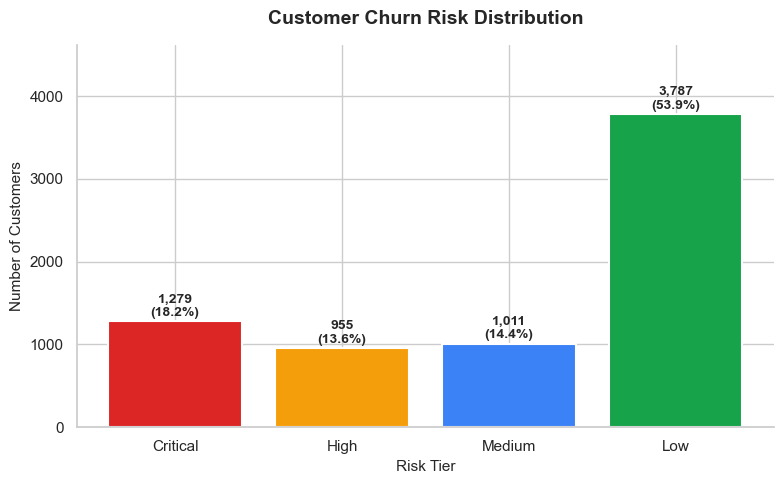

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    TIER_ORDER,
    summary['customers'],
    color=[TIER_COLORS[t] for t in TIER_ORDER],
    edgecolor='white',
    linewidth=1.5,
)

for bar, tier in zip(bars, TIER_ORDER):
    n   = summary.loc[tier, 'customers']
    pct = summary.loc[tier, 'pct_of_base']
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 25,
        f'{n:,}\n({pct}%)',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_title('Customer Churn Risk Distribution', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Risk Tier', fontsize=11)
ax.set_ylabel('Number of Customers', fontsize=11)
ax.set_ylim(0, summary['customers'].max() * 1.22)
sns.despine()
plt.tight_layout()
plt.show()

### Customer Profile by Risk Tier

Higher-risk customers tend to pay more per month but have shorter tenure while
recent, high-spend customers who haven't yet built loyalty are the most vulnerable segment.

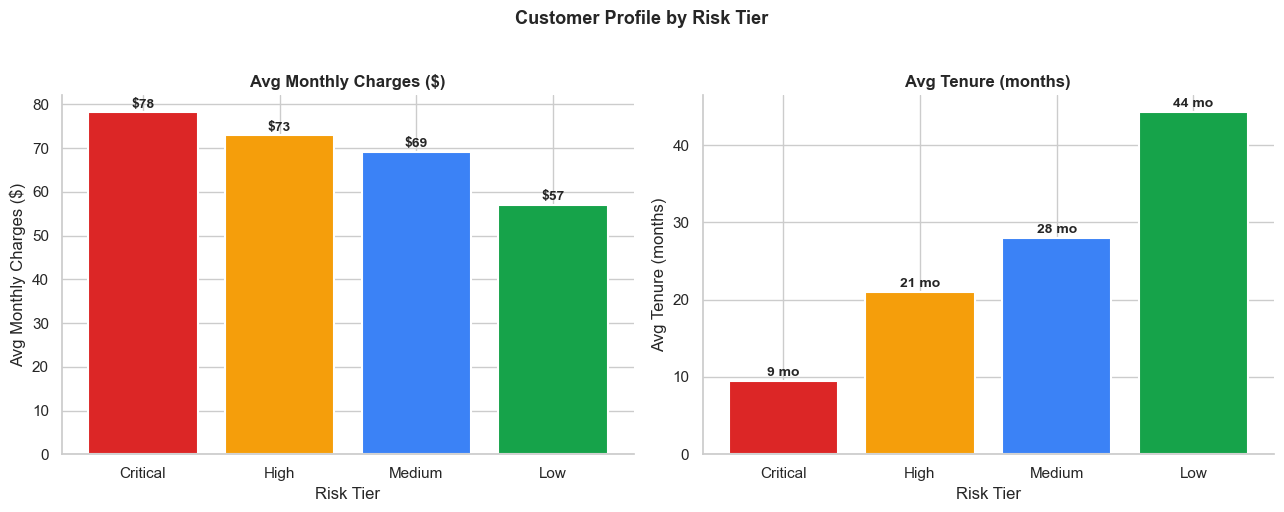

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

metrics = [
    ('MonthlyCharges', 'Avg Monthly Charges ($)', '${:.0f}'),
    ('tenure',          'Avg Tenure (months)',      '{:.0f} mo'),
]

for ax, (col, label, fmt) in zip(axes, metrics):
    vals   = [scored.loc[scored['risk_tier'] == t, col].mean() for t in TIER_ORDER]
    colors = [TIER_COLORS[t] for t in TIER_ORDER]
    bars   = ax.bar(TIER_ORDER, vals, color=colors, edgecolor='white', linewidth=1.5)
    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            fmt.format(v),
            ha='center', va='bottom', fontsize=10, fontweight='bold'
        )
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Risk Tier')
    ax.set_ylabel(label)
    sns.despine()

plt.suptitle('Customer Profile by Risk Tier', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Save Scored Customer List

The output CSV contains one row per customer with all fields needed for CRM upload or direct handoff to the retention team.

In [11]:
output_cols = ['customer_id', 'churn_probability', 'risk_tier', 'predicted_churn',
               'tenure', 'MonthlyCharges', 'Contract']

output_path = PROCESSED_DIR / 'churn_scored_customers.csv'
scored[output_cols].to_csv(output_path, index=False)

print(f'Saved  : {output_path}')
print(f'Rows   : {len(scored):,}')
print(f'Cols   : {output_cols}')
print()
display(scored[output_cols].head(10))

Saved  : C:\Users\Ahana\Desktop\telco-churn-ml-lab\data\processed\churn_scored_customers.csv
Rows   : 7,032
Cols   : ['customer_id', 'churn_probability', 'risk_tier', 'predicted_churn', 'tenure', 'MonthlyCharges', 'Contract']



,customer_id,churn_probability,risk_tier,predicted_churn,tenure,MonthlyCharges,Contract
0,1,0.8493,Critical,1,1,29.85,Month-to-month
1,2,0.1081,Low,0,34,56.95,Longer-term
2,3,0.3680,Medium,1,2,53.85,Month-to-month
3,4,0.1458,Low,0,45,42.30,Longer-term
4,5,0.9280,Critical,1,2,70.70,Month-to-month
5,6,0.9129,Critical,1,8,99.65,Month-to-month
6,7,0.3790,Medium,1,22,89.10,Month-to-month
7,8,0.3580,Medium,1,10,29.75,Month-to-month
8,9,0.6830,High,1,28,104.80,Month-to-month
9,10,0.0485,Low,0,62,56.15,Longer-term


### Next Steps from a business standpoint: 

### Immediate: Critical tier
- Export the Critical tier list and route to the retention team **today**
- Prioritise customers with high `MonthlyCharges` as they represent the greatest revenue at risk
- Fiber optic + month-to-month customers dominate this tier; a targeted contract-upgrade offer
  (e.g. 3-month discount for switching to a 1-year plan) is likely cost-effective

### Short-term: High tier
- Schedule outreach within **5–7 business days**
- Focus on `contract_payment_risk` customers (month-to-month + electronic check) thus, nudging them toward auto-pay removes a key churn friction point without requiring a discount

### Ongoing monitoring
- Re-score the full customer base **monthly** as new billing and usage data arrives
- Track whether contacted customers at each tier actually churned and 
  use this feedback loop to calibrate the threshold and retrain the model quarterly
- If the retention team is overloaded, raise `THRESHOLD` above 0.3 to reduce volume;
  if budget allows more outreach, lower it further and monitor precision